# Projeto Integrador — Análise Exploratória (UCI Credit Card)

Nomes: Lucas Souza Santos, Ali Ahmad, Leonardo Tonon

Notebook limpo e reorganizado em português. Responde às questões: escolha do tema/base, compreensão dos dados, estatísticas, visualizações, outliers, segmentações, tendências temporais e aplicações.

## 1) Escolha do Tema
Análise exploratória para identificar fatores associados à inadimplência de cartões de crédito e gerar insights para gestão de risco.

## 2) Escolha da Base
A base utilizada foi Default of Credit Card Clients Dataset, disponível no repositório UCI Machine Learning Repository.

Link da base:
https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

A base contém dados de aproximadamente 30.000 clientes, incluindo informações demográficas, limite de crédito, histórico de faturas, histórico de pagamentos e a variável alvo default.payment.next.month, que indica se o cliente entrou em inadimplência no mês seguinte.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

csv_path = '/content/UCI_Credit_Card.csv'
try:
    df = pd.read_csv(csv_path)
    print(f'Dataset carregado: {csv_path}')
except Exception as e:
    print('Erro ao carregar CSV:', e)
    try:
        df = pd.read_csv('UCI_Credit_Card.csv')
        print('Dataset carregado: UCI_Credit_Card.csv (raiz do workspace)')
    except Exception as e2:
        print('Falha ao localizar o arquivo. Coloque o CSV em /content/ ou na raiz do workspace.')
        raise

df.head()

Dataset carregado: /content/UCI_Credit_Card.csv


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 3) Compreensão dos dados
Respostas automáticas e verificações: estrutura, tipos, nulos e duplicados.

In [2]:
print('Shape (linhas, colunas):', df.shape)
print('\nTipos de dados:')
print(df.dtypes)

print('\nValores ausentes por coluna:')
print(df.isnull().sum())

print('\nLinhas duplicadas (total):', df.duplicated().sum())

# Verificar colunas categóricas esperadas
for col in ['SEX','EDUCATION','MARRIAGE']:
    if col in df.columns:
        print(f"\nContagens - {col}:\n", df[col].value_counts(dropna=False))

# Criar faixa etária
if 'AGE' in df.columns:
    bins = [0,20,30,40,50,60,70,120]
    labels = ['<20','20-29','30-39','40-49','50-59','60-69','70+']
    df['AGE_GROUP'] = pd.cut(df['AGE'], bins=bins, labels=labels, right=False)
    print('\nContagem por AGE_GROUP:')
    print(df['AGE_GROUP'].value_counts())

Shape (linhas, colunas): (30000, 25)

Tipos de dados:
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      in

## 3c/d Resumo curto (comportamento detectado)
- Estrutura: linhas x colunas acima.
- Tipos: mistura de numéricas contínuas e variáveis categóricas codificadas numericamente.
- Valores ausentes: verificado por isnull().
- Duplicados: verificado e exibido.

## 4) Estatísticas Descritivas
Calcular médias, medianas, min, max e desvio padrão para variáveis numéricas relevantes.

In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Colunas numéricas:', len(num_cols))
describe = df[num_cols].describe().T
# adicionar mediana
describe['median'] = df[num_cols].median()
# selecionar colunas de interesse para exibir
display_cols = ['count','mean','median','std','min','25%','50%','75%','max']
display(describe[display_cols])

Colunas numéricas: 25


,count,mean,median,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,15000.5,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,140000.0,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,2.0,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,2.0,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,2.0,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,34.0,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,0.0,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,0.0,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,0.0,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,0.0,1.169139,-2.0,-1.00,0.0,0.00,8.0


## 5) Visualização e Padrões
5a) Correlação entre variáveis numéricas. 5b) Histogramas e boxplots para LIMIT_BAL, AGE, BILL_AMT1..6, PAY_AMT1..6.

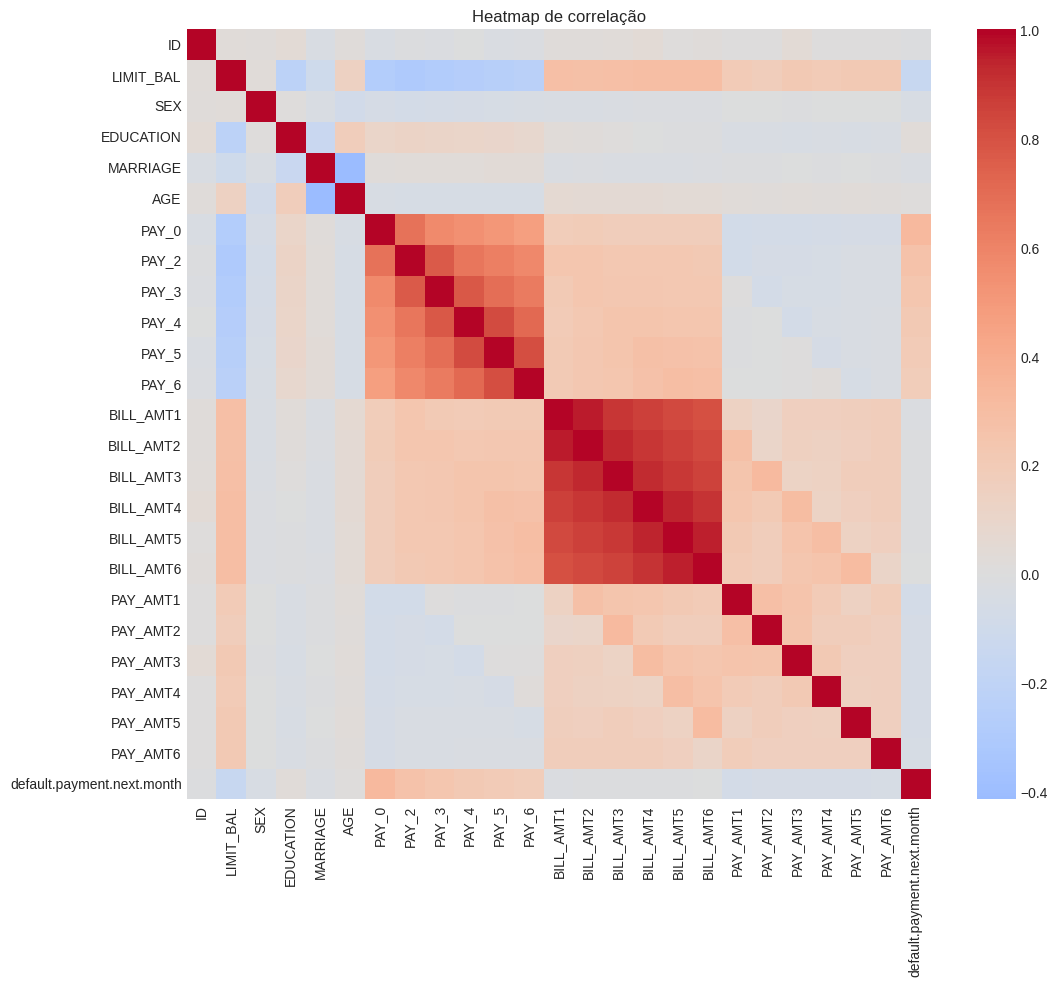

In [4]:
corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatmap de correlação')
plt.show()

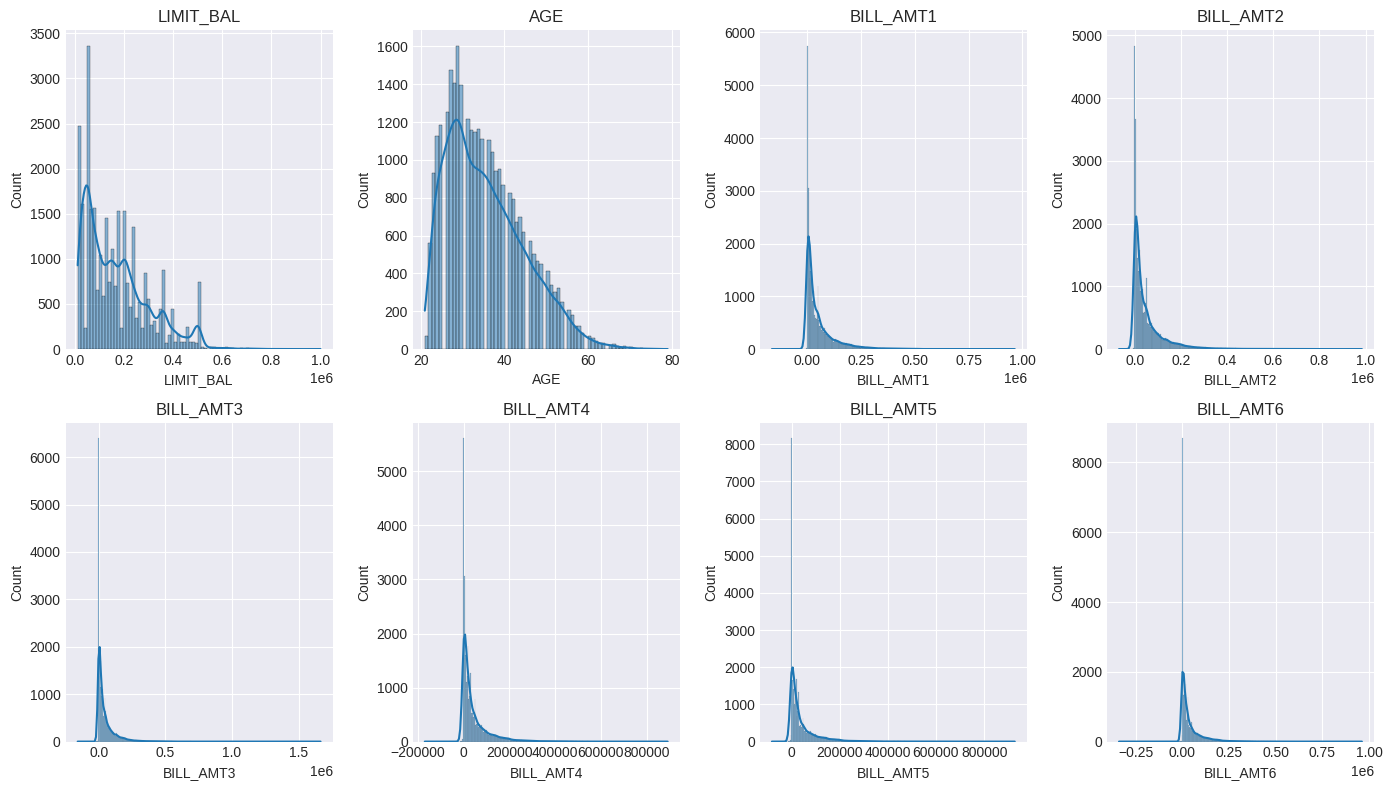

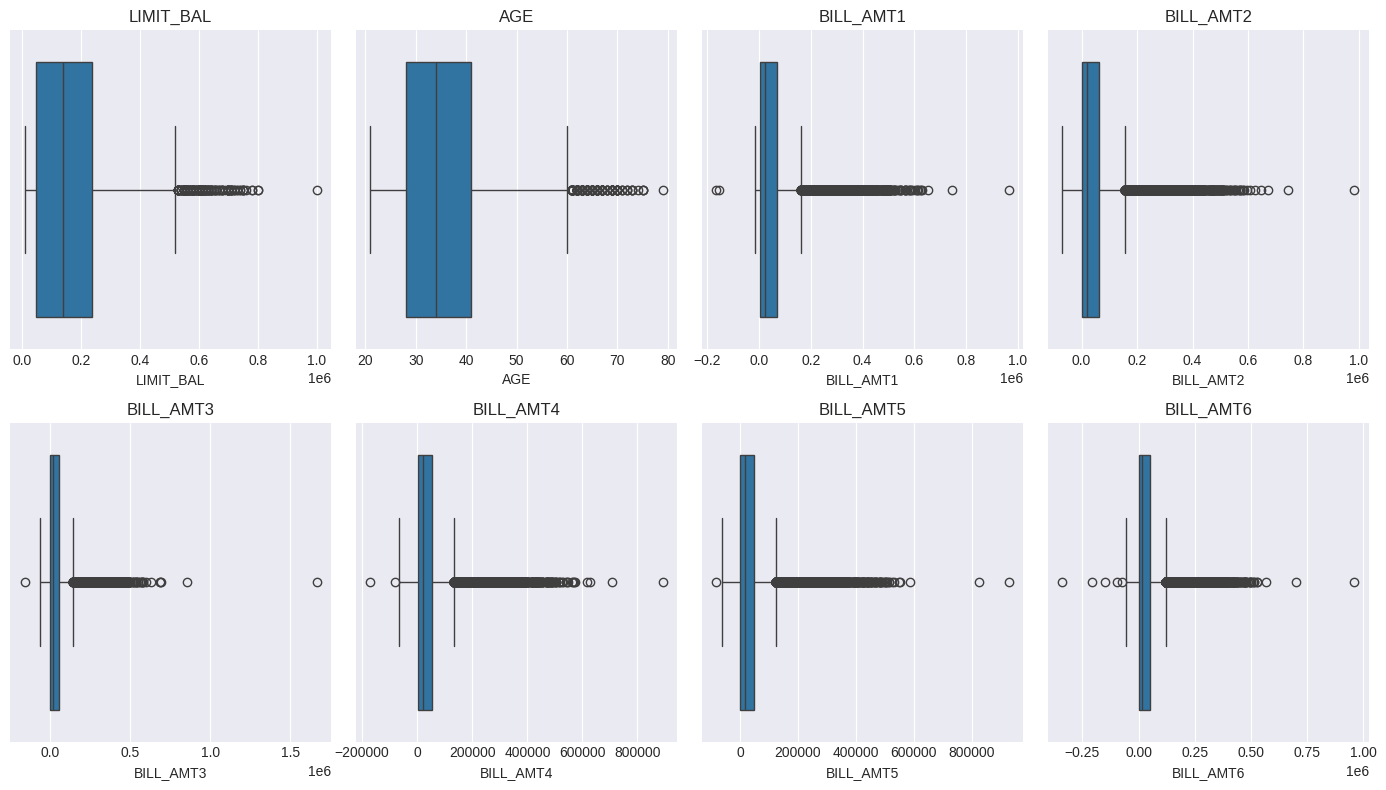

In [5]:
# Histogramas e boxplots (selecionadas)
cols_hist = ['LIMIT_BAL','AGE'] + [f'BILL_AMT{i}' for i in range(1,7) if f'BILL_AMT{i}' in df.columns]
cols_hist = [c for c in cols_hist if c in df.columns]

plt.figure(figsize=(14,8))
for i, col in enumerate(cols_hist,1):
    plt.subplot(2, 4, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,8))
for i, col in enumerate(cols_hist,1):
    plt.subplot(2, 4, i)
    sns.boxplot(x=df[col].dropna())
    plt.title(col)
plt.tight_layout()
plt.show()

## 6) Outliers e Anomalias
6a) Identificação por IQR; 6b) anomalias em categorias (EDUCATION, MARRIAGE).

In [6]:
# Contagem de outliers por IQR para colunas financeiras
fin_cols = [c for c in ['LIMIT_BAL'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)] if c in df.columns]
outliers = {}
for c in fin_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    out_count = df[(df[c] < low) | (df[c] > high)].shape[0]
    outliers[c] = out_count
print('Outliers (IQR) por coluna:')
for k,v in outliers.items():
    print(f'{k}: {v} ({v/len(df):.2%})')

# Anomalias categóricas
for c in ['EDUCATION','MARRIAGE']:
    if c in df.columns:
        print(f"\nCategorias em {c}:\n", df[c].value_counts())

Outliers (IQR) por coluna:
LIMIT_BAL: 167 (0.56%)
BILL_AMT1: 2400 (8.00%)
BILL_AMT2: 2395 (7.98%)
BILL_AMT3: 2469 (8.23%)
BILL_AMT4: 2622 (8.74%)
BILL_AMT5: 2725 (9.08%)
BILL_AMT6: 2693 (8.98%)
PAY_AMT1: 2745 (9.15%)
PAY_AMT2: 2714 (9.05%)
PAY_AMT3: 2598 (8.66%)
PAY_AMT4: 2994 (9.98%)
PAY_AMT5: 2945 (9.82%)
PAY_AMT6: 2958 (9.86%)

Categorias em EDUCATION:
 EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

Categorias em MARRIAGE:
 MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


## 7) Comparações e Segmentações
7a) Taxa de inadimplência por sexo, escolaridade, estado civil e faixa etária.
7b) Comportamento ao longo do tempo (médias de PAY_X, BILL_AMT, PAY_AMT).
7c) Insights para decisão.


Taxa de inadimplência por SEX:
SEX
1    24.17%
2    20.78%
Name: default.payment.next.month, dtype: object

Taxa de inadimplência por EDUCATION:
EDUCATION
0     0.00%
1    19.23%
2    23.73%
3    25.16%
4     5.69%
5     6.43%
6    15.69%
Name: default.payment.next.month, dtype: object

Taxa de inadimplência por MARRIAGE:
MARRIAGE
0     9.26%
1    23.47%
2    20.93%
3    26.01%
Name: default.payment.next.month, dtype: object

Taxa de inadimplência por AGE_GROUP:
AGE_GROUP
<20        nan%
20-29    22.84%
30-39    20.25%
40-49    22.97%
50-59    24.86%
60-69    28.34%
70+      28.00%
Name: default.payment.next.month, dtype: object


/tmp/ipykernel_510/680024134.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(c)[alvo].mean().apply(lambda x: f'{x:.2%}'))


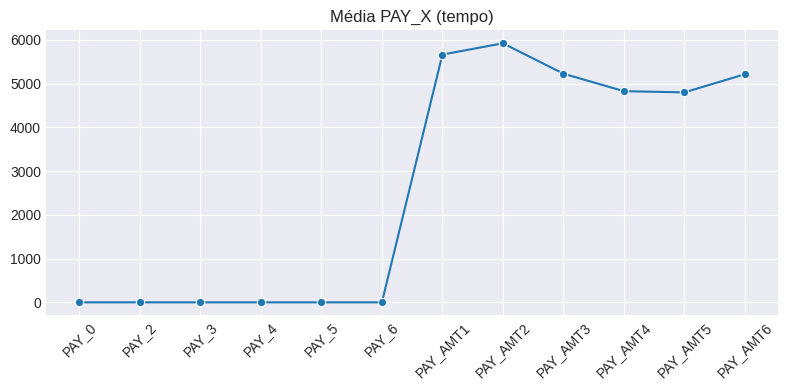

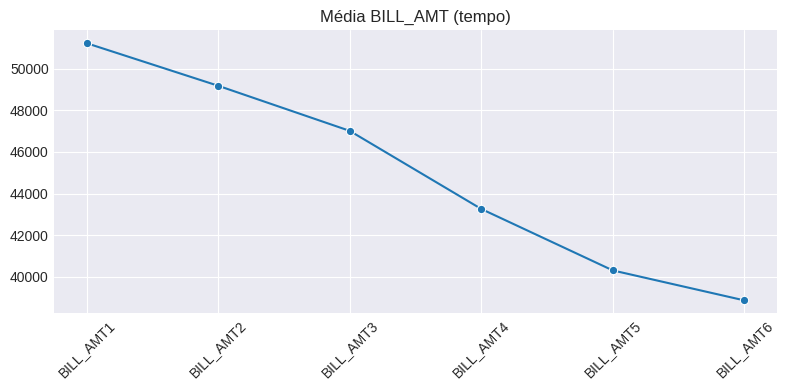

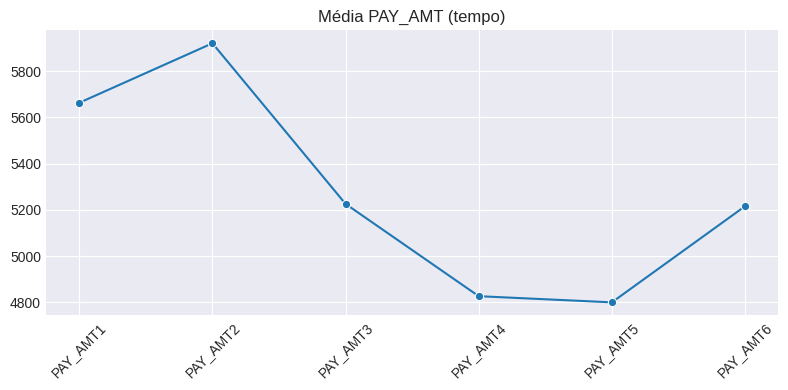

In [7]:
# Verificar coluna alvo
alvo = 'default.payment.next.month'
if alvo not in df.columns:
    print('Coluna alvo não encontrada:', alvo)
else:
    def fmt_rate(s):
        return s.mean().apply(lambda x: f'{x:.2%}') if hasattr(s, 'mean') else ''

    for c in ['SEX','EDUCATION','MARRIAGE','AGE_GROUP']:
        if c in df.columns:
            print(f"\nTaxa de inadimplência por {c}:")
            print(df.groupby(c)[alvo].mean().apply(lambda x: f'{x:.2%}'))

# Tendências temporais
pay_cols = [col for col in df.columns if col.startswith('PAY_')]
bill_cols = [col for col in df.columns if col.startswith('BILL_AMT')]
pay_amt_cols = [col for col in df.columns if col.startswith('PAY_AMT')]

pay_means = df[pay_cols].mean() if pay_cols else pd.Series()
bill_means = df[bill_cols].mean() if bill_cols else pd.Series()
pay_amt_means = df[pay_amt_cols].mean() if pay_amt_cols else pd.Series()

# rótulos de meses (apenas ilustrativos: BILL_AMT1 = Set etc.)
months = ['Set','Ago','Jul','Jun','Mai','Abr']

if not pay_means.empty:
    plt.figure(figsize=(8,4))
    sns.lineplot(x=range(len(pay_means)), y=pay_means.values, marker='o')
    plt.xticks(range(len(pay_means)), pay_means.index, rotation=45)
    plt.title('Média PAY_X (tempo)')
    plt.tight_layout(); plt.show()

if not bill_means.empty:
    plt.figure(figsize=(8,4))
    sns.lineplot(x=range(len(bill_means)), y=bill_means.values, marker='o')
    plt.xticks(range(len(bill_means)), bill_means.index, rotation=45)
    plt.title('Média BILL_AMT (tempo)')
    plt.tight_layout(); plt.show()

if not pay_amt_means.empty:
    plt.figure(figsize=(8,4))
    sns.lineplot(x=range(len(pay_amt_means)), y=pay_amt_means.values, marker='o')
    plt.xticks(range(len(pay_amt_means)), pay_amt_means.index, rotation=45)
    plt.title('Média PAY_AMT (tempo)')
    plt.tight_layout(); plt.show()

## 8) Contextualização e Aplicação
Resuma e aplique os insights: ações de negócio e avaliação da pertinência da base para o problema.

### Resumo executivo (ações recomendadas)
- Agrupar categorias ruidosas: EDUCATION (0,4,5,6) → 'Outros'; MARRIAGE (0) → 'Desconhecido/Outros'.
- Tratar outliers em variáveis financeiras (capping ou transformação log).
- Criar features: taxa de utilização do limite, média de atrasos, variação mensal da fatura.
- Construir modelos de scoring usando histórico PAY_X e BILL_AMT como principais preditores.

## Q&A — Respostas diretas às perguntas solicitadas
1) Escolha do Tema: Predição/entendimento de inadimplência em cartão de crédito.
2) Escolha da Base: UCI Credit Card (histórico de 6 meses + demográficos + alvo `default.payment.next.month`).
3a) Estrutura: ver célula de `df.shape` (ex.: 30000 x 25).
3b) Tipos de variáveis:

O dataset possui diferentes tipos de variáveis:

Variáveis numéricas contínuas:
LIMIT_BAL, BILL_AMT1 a BILL_AMT6, PAY_AMT1 a PAY_AMT6 e AGE.

Variáveis categóricas codificadas numericamente:
SEX, EDUCATION e MARRIAGE.

Variáveis de histórico de pagamento:
PAY_0 a PAY_6, que representam o status de atraso nos pagamentos em meses anteriores.

Variável alvo:
default.payment.next.month, que indica se o cliente entrou em inadimplência no mês seguinte.
3c) 3c) Valores ausentes:

A verificação de valores ausentes foi realizada utilizando o método `df.isnull().sum()`.

No dataset original não foram encontrados valores ausentes.

Caso existissem valores ausentes, algumas estratégias possíveis seriam:

- remoção de registros incompletos
- substituição pela média ou mediana das variáveis numéricas
- utilização de técnicas de imputação estatística
3d) Duplicados/inconsistências: ver `df.duplicated()` e `value_counts()`; anomalias em EDUCATION/MARRIAGE detectadas.
4a) Estatísticas básicas: ver `df.describe()`; média, mediana, min, max e std exibidos na seção 4.
5a) Relações:

O heatmap de correlação mostra forte correlação entre as variáveis BILL_AMT1 até BILL_AMT6, indicando que os clientes tendem a manter padrões semelhantes de gastos ao longo dos meses.

Também é possível observar relação entre o histórico de atraso de pagamentos (PAY_X) e a variável de inadimplência.
5b) Visualizações: histogramas, boxplots e heatmap implementados.
6a) Outliers: contagem por IQR mostrada;
6b) Anomalias: categorias 0,4,5,6 em EDUCATION e 0 em MARRIAGE precisariam recodificação.
7a) Diferenças por grupo: taxas de inadimplência por SEX/EDUCATION/MARRIAGE/AGE_GROUP exibidas;
7b) Comportamento ao longo do tempo:

A base apresenta histórico de pagamentos e valores de faturas referentes aos últimos seis meses. Isso permite observar a evolução do comportamento financeiro dos clientes ao longo desse período.
7c) Insights:

A análise indica que variáveis relacionadas ao histórico de pagamento (PAY_X) são fortes indicadores de inadimplência.

Clientes que apresentam atrasos frequentes possuem maior probabilidade de entrar em default.

Além disso, os valores de fatura (BILL_AMT) apresentam comportamento consistente ao longo dos meses, o que pode ajudar na identificação de padrões de consumo e perfis de risco.
8a) Aplicação:

Os insights obtidos podem ser utilizados por instituições financeiras para:

- desenvolvimento de modelos de credit scoring
- definição de limites de crédito mais adequados
- identificação de clientes com maior risco de inadimplência
- criação de estratégias de cobrança preventiva

Essas ações auxiliam na gestão de risco e na tomada de decisões relacionadas à concessão de crédito.
8b) Pertinência: sim — base adequada para modelagem de inadimplência.

---

Observação: revise caminhos de arquivo antes de executar; salve backups se desejar manter o notebook original.